### [Financial Analysis and Stock Market Predictions](https://medium.com/pythoneers/python-for-financial-analysis-and-stock-market-predictions-5b420335487a)

In [1]:
!pip install --quiet yfinance

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

In [3]:
# Fetch stock data for Apple
ticker = yf.Ticker("AAPL")
data = ticker.history(period="5y")

display(data.sample(10))

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-02-28 00:00:00-05:00,159.913168,162.227624,159.295321,161.933411,95056600,0.0,0.0
2024-02-26 00:00:00-05:00,180.765416,181.281197,179.188270,179.694153,40867400,0.0,0.0
2023-04-05 00:00:00-04:00,162.539430,162.845287,159.638700,161.572510,51511700,0.0,0.0
2025-11-06 00:00:00-05:00,267.630574,273.135217,267.630574,269.508728,51204000,0.0,0.0
2022-06-01 00:00:00-04:00,147.223073,149.030225,145.042717,146.054337,74286600,0.0,0.0
2024-08-06 00:00:00-04:00,203.915013,208.573376,199.713553,205.831985,69660500,0.0,0.0
2024-09-27 00:00:00-04:00,227.181431,228.235496,226.027919,226.515167,34026000,0.0,0.0
2022-03-23 00:00:00-04:00,164.747998,169.308252,164.414548,166.925156,98062700,0.0,0.0
2025-06-12 00:00:00-04:00,198.661736,199.260466,196.945348,198.781479,43904600,0.0,0.0


In [4]:
display(data.head())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,129.975354,130.062961,123.394814,125.974464,143301900,0.0,0.0
2021-01-05 00:00:00-05:00,125.468261,128.242606,125.020466,127.531975,97664900,0.0,0.0
2021-01-06 00:00:00-05:00,124.329329,127.570927,123.024899,123.239059,155088000,0.0,0.0
2021-01-07 00:00:00-05:00,124.952339,128.135532,124.465612,127.444374,109578200,0.0,0.0
2021-01-08 00:00:00-05:00,128.914274,129.108977,126.772682,128.544373,105158200,0.0,0.0


In [5]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 00:00:00-05:00 to 2025-12-31 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1255 non-null   float64
 1   High          1255 non-null   float64
 2   Low           1255 non-null   float64
 3   Close         1255 non-null   float64
 4   Volume        1255 non-null   int64  
 5   Dividends     1255 non-null   float64
 6   Stock Splits  1255 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


None

In [6]:
display(data.describe())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03,1255.000000,1255.0
mean,179.363037,181.307993,177.597873,179.541256,6.981550e+07,0.003781,0.0
std,40.044076,40.317637,39.810083,40.092456,2.996296e+07,0.029785,0.0
min,116.043170,117.378796,113.293940,113.440178,1.791060e+07,0.000000,0.0
25%,145.913022,147.745771,144.642973,146.091026,4.834280e+07,0.000000,0.0
50%,171.512100,173.216346,169.810972,171.681564,6.313550e+07,0.000000,0.0
75%,210.127598,212.774853,208.100074,210.706375,8.453615e+07,0.000000,0.0
max,286.200012,288.619995,283.299988,286.190002,3.186799e+08,0.260000,0.0


In [7]:
display(data.isna().sum())

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


In [8]:
display(data.isnull().sum())

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


#### Cleaning and Preparing Financial Data

In [9]:
# Handle missing values
data = data.dropna()

# Create new feature: daily returns
data["Daily_Return"] = data["Close"].pct_change()

# Moving averages
data["MA_50"] = data["Close"].rolling(50).mean()
data["MA_200"] = data["Close"].rolling(200).mean()

display(data.tail())

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Daily_Return,MA_50,MA_200
Date,,,,,,,,,,
2025-12-24 00:00:00-05:00,272.339996,275.429993,272.200012,273.809998,17910600,0.0,0.0,0.005324,270.954561,230.201515
2025-12-26 00:00:00-05:00,274.160004,275.369995,272.859985,273.399994,21521800,0.0,0.0,-0.001497,271.440591,230.487312
2025-12-29 00:00:00-05:00,272.690002,274.359985,272.350006,273.760010,23715200,0.0,0.0,0.001317,271.971584,230.811285
2025-12-30 00:00:00-05:00,272.809998,274.079987,272.279999,273.079987,22139600,0.0,0.0,-0.002484,272.392271,231.112873
2025-12-31 00:00:00-05:00,273.059998,273.679993,271.750000,271.859985,27293600,0.0,0.0,-0.004468,272.589750,231.405819


#### Visualizing Stock Trends with Matplotlib

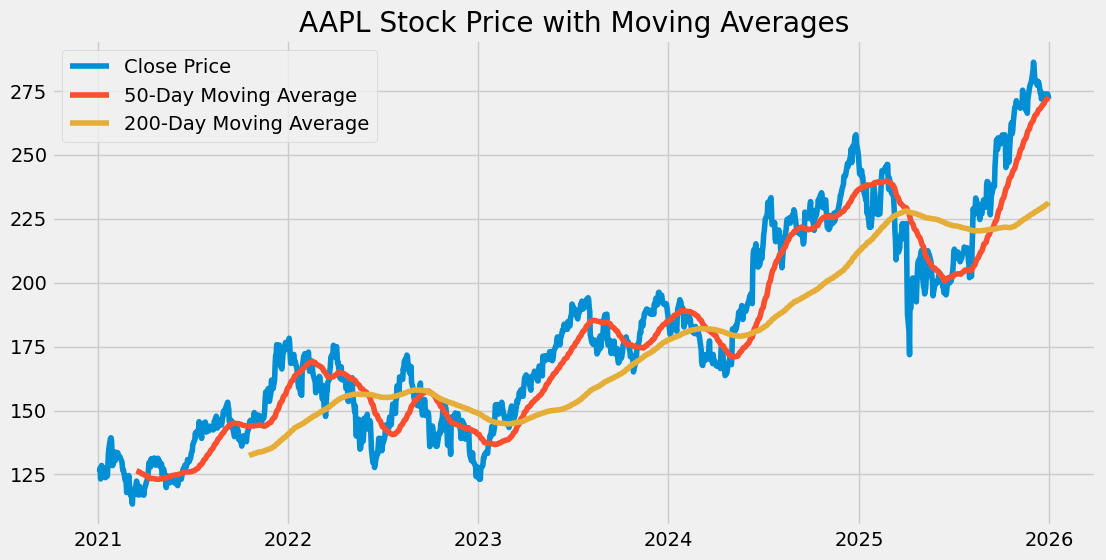

In [10]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Close Price")
plt.plot(data["MA_50"], label="50-Day Moving Average")
plt.plot(data["MA_200"], label="200-Day Moving Average")
plt.legend()
plt.title("AAPL Stock Price with Moving Averages")
plt.show()

#### Statistical Analysis - Descriptive Statistics and Correlation Analysis

In [11]:
# Correlation between returns and volume
correlation = data["Daily_Return"].corr(data["Volume"])
print(f"Correlation between returns and volume: {correlation:.4f}")

# Rolling volatility
data["Volatility"] = data["Daily_Return"].rolling(30).std()

display(data[["Daily_Return", "Volatility"]].tail())

Correlation between returns and volume: -0.0009


,Daily_Return,Volatility
Date,,
2025-12-24 00:00:00-05:00,0.005324,0.008968
2025-12-26 00:00:00-05:00,-0.001497,0.008893
2025-12-29 00:00:00-05:00,0.001317,0.008888
2025-12-30 00:00:00-05:00,-0.002484,0.008892
2025-12-31 00:00:00-05:00,-0.004468,0.008249


#### Building a Machine Learning Model for Predictions

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Create target: 1 if price goes up tomorrow, 0 otherwise
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

display(data.sample(20))

features = ["Daily_Return", "MA_50", "MA_200", "Volatility"]
#X = data[features].dropna()
#y = data["Target"].dropna()

# Combine features and target into a temporary DataFrame
temp_df = data[features + ["Target"]].copy()

# Drop rows where any of the relevant columns have NaN values, ensuring X and y are aligned
temp_df.dropna(inplace=True)

X = temp_df[features]
y = temp_df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Prediction Accuracy: {accuracy:.4f}")

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Daily_Return,MA_50,MA_200,Volatility,Target
Date,,,,,,,,,,,,
2021-11-29 00:00:00-05:00,156.095497,157.878110,155.527412,156.947632,88748200,0.0,0.0,0.021874,145.375724,135.114004,0.012818,1
2025-09-11 00:00:00-04:00,226.660277,230.226812,226.430489,229.807220,50208600,0.0,0.0,0.014286,220.350096,220.815456,0.018694,1
2024-08-13 00:00:00-04:00,217.784316,220.648203,217.784316,220.031677,44155300,0.0,0.0,0.017193,214.415067,189.351985,0.016641,1
2024-04-29 00:00:00-04:00,171.967162,174.605642,171.699358,172.096115,68169400,0.0,0.0,0.024808,171.678333,179.812393,0.015694,0
2024-07-15 00:00:00-04:00,234.884680,235.629621,231.517550,232.818710,62631300,0.0,0.0,0.016743,200.903805,184.667350,0.018830,1
2023-09-22 00:00:00-04:00,172.808179,175.192494,172.194793,172.926895,56725400,0.0,0.0,0.004944,181.335009,163.379173,0.014906,1
2023-06-12 00:00:00-04:00,179.095988,181.684561,178.799583,181.585754,54274900,0.0,0.0,0.015639,168.647963,150.558759,0.011899,0
2024-10-07 00:00:00-04:00,223.243597,224.426940,220.091340,220.449326,39505400,0.0,0.0,-0.022531,221.453286,196.633405,0.014228,1
2025-04-14 00:00:00-04:00,210.719450,212.214338,200.474483,201.829849,101352900,0.0,0.0,0.022054,223.031790,227.287010,0.042363,0


Prediction Accuracy: 0.4906


#### Time Series Forecasting with ARIMA

In [13]:
from statsmodels.tsa.arima.model import ARIMA

# Use only closing prices
series = data["Close"]

# Train ARIMA model
model = ARIMA(series, order=(5,1,0))
model_fit = model.fit()

# Forecast next 10 days
forecast = model_fit.forecast(steps=10)
print("Forecasted Prices:")
display(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Forecasted Prices:


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,predicted_mean
1255,271.752310
1256,271.764481
1257,271.825369
1258,271.877789
1259,271.914009
1260,271.916022
1261,271.912536
1262,271.908023
1263,271.905533
1264,271.904549


#### Deep Learning with LSTMs

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data["Close"].values.reshape(-1,1))

X_train, y_train = [], []
for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")
model.fit(X_train, y_train, epochs=10, batch_size=32)

model.summary()

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0462
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0023
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0018
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0017
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0016
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0015
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0015
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0014
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0014
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - loss: 0.0013


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

#### Risk Analysis and Portfolio Optimization

In [15]:
returns = data["Daily_Return"].dropna()
mean_return = returns.mean() * 252
volatility = returns.std() * np.sqrt(252)

sharpe_ratio = mean_return / volatility
print(f"Expected Annual Return: {mean_return:.4f}")
print(f"Annual Volatility: {volatility:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Expected Annual Return: 0.1932
Annual Volatility: 0.2786
Sharpe Ratio: 0.6935
